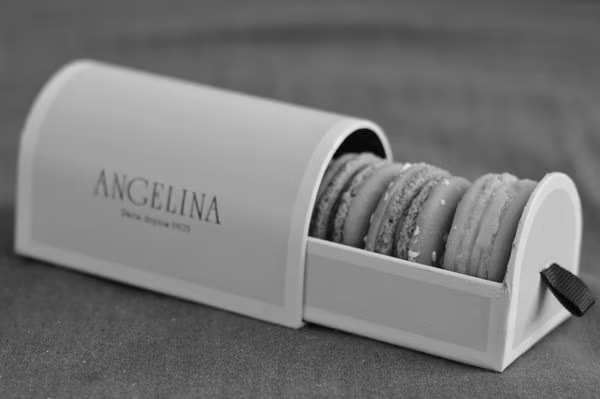

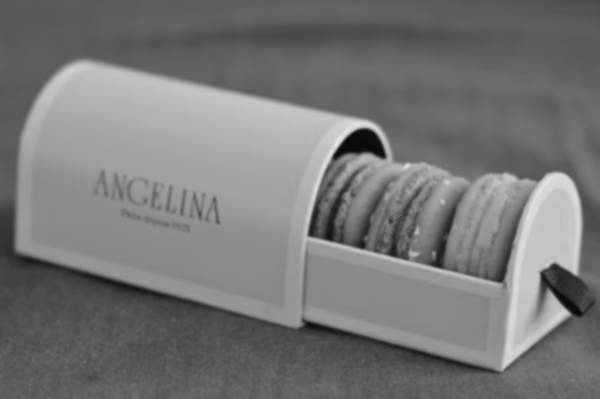

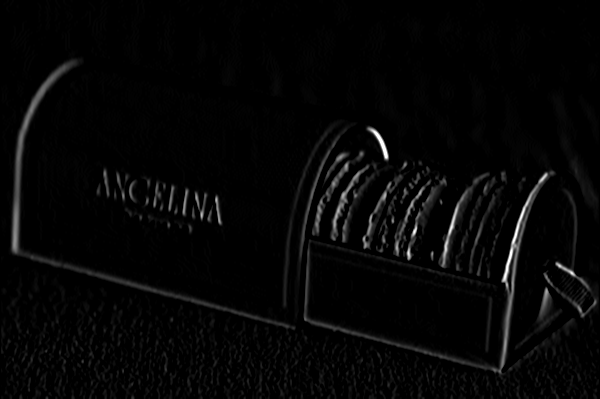

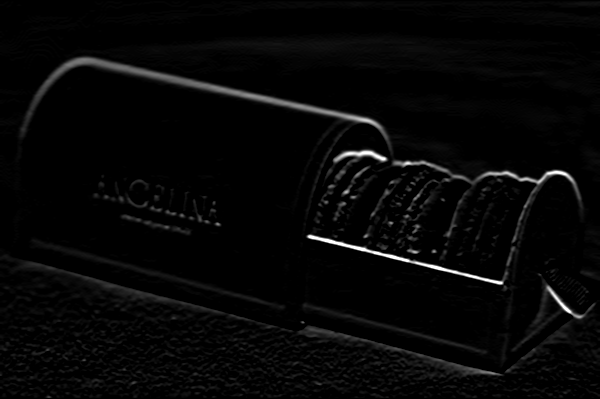

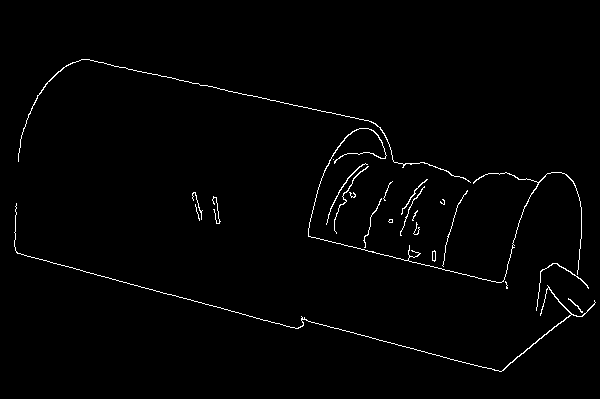

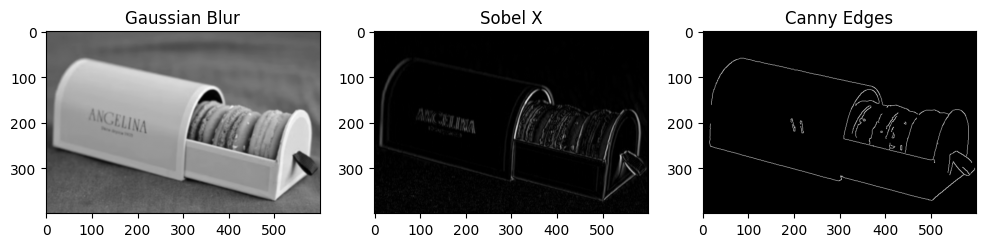

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files

# 1. Load and Pre-process
# Using a placeholder for class usage; students can upload via
#files.upload()
img = cv2.imread('/content/drive/MyDrive/AI_and_Robotics/Cookie_box.png', cv2.IMREAD_GRAYSCALE)
cv2_imshow(img)
# 2. Noise Reduction (Mandatory for Canny)
# ksize must be odd. 5x5 is standard for industrial inspection.
blurred = cv2.GaussianBlur(img, (5, 5), 0)
cv2_imshow(blurred)
# 3. Sobel Gradient (Directional Edges)
sobelx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3) # Horizontal
sobely = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3) # Vertical
cv2_imshow(sobelx)
cv2_imshow(sobely)
# 4. Canny Edge Detection (Structural Skeleton)
# threshold1: lower bound, threshold2: upper bound (Hysteresis)
edges = cv2.Canny(blurred, 100, 200)
cv2_imshow(edges)
# Visualization
plt.figure(figsize=(12, 6))
plt.subplot(131), plt.imshow(blurred, cmap='gray'), plt.title('Gaussian Blur')
plt.subplot(132), plt.imshow(np.abs(sobelx), cmap='gray'), plt.title('Sobel X')
plt.subplot(133), plt.imshow(edges, cmap='gray'), plt.title('Canny Edges')
plt.show()

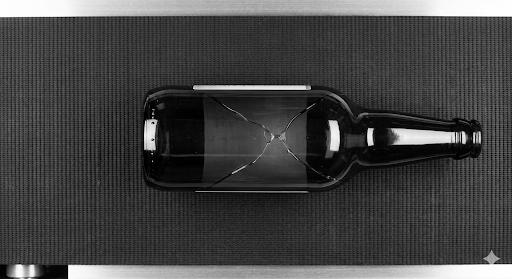

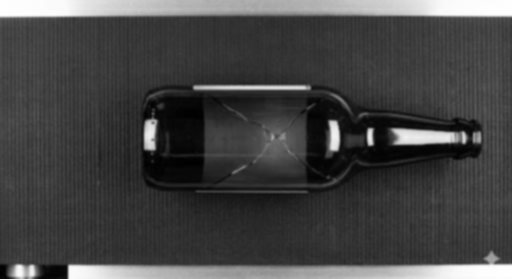

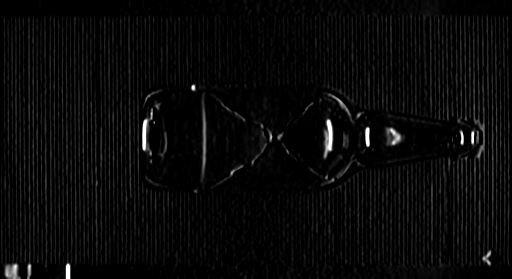

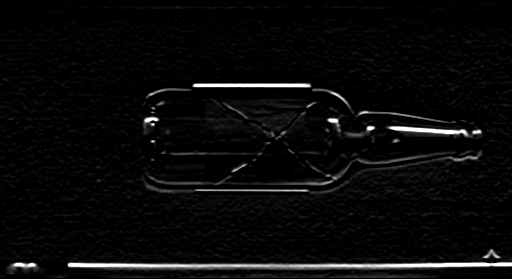

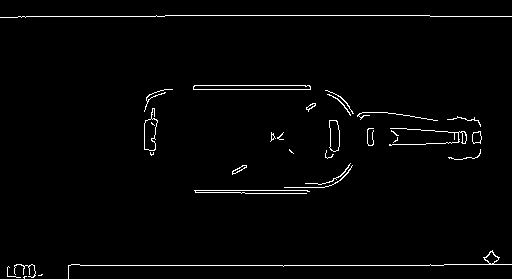

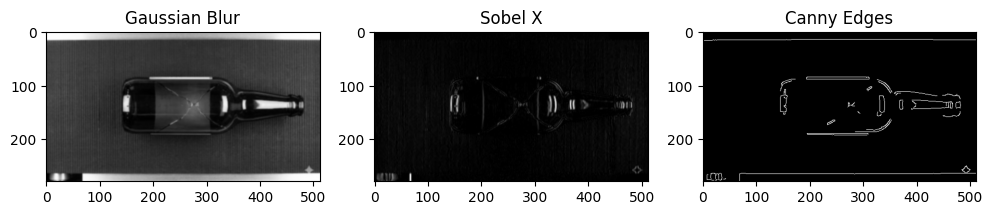

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files

# 1. Load and Pre-process
# Using a placeholder for class usage; students can upload via
#files.upload()
img = cv2.imread('/content/cracked.jpeg', cv2.IMREAD_GRAYSCALE)
cv2_imshow(img)
# 2. Noise Reduction (Mandatory for Canny)
# ksize must be odd. 5x5 is standard for industrial inspection.
blurred = cv2.GaussianBlur(img, (5, 5), 0)
cv2_imshow(blurred)
# 3. Sobel Gradient (Directional Edges)
sobelx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3) # Horizontal
sobely = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3) # Vertical
cv2_imshow(sobelx)
cv2_imshow(sobely)
# 4. Canny Edge Detection (Structural Skeleton)
# threshold1: lower bound, threshold2: upper bound (Hysteresis)
edges = cv2.Canny(blurred, 100, 200)
cv2_imshow(edges)
# Visualization
plt.figure(figsize=(12, 6))
plt.subplot(131), plt.imshow(blurred, cmap='gray'), plt.title('Gaussian Blur')
plt.subplot(132), plt.imshow(np.abs(sobelx), cmap='gray'), plt.title('Sobel X')
plt.subplot(133), plt.imshow(edges, cmap='gray'), plt.title('Canny Edges')
plt.show()


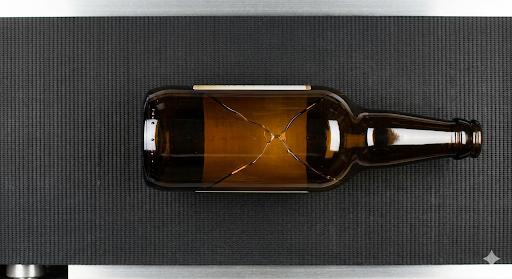

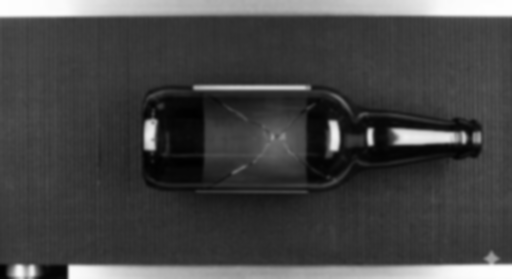

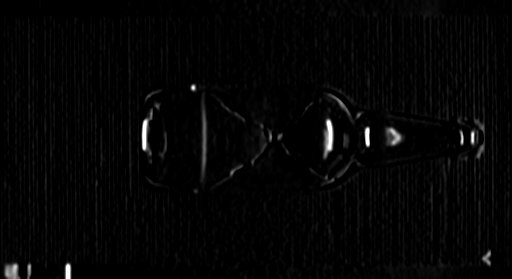

sobelx


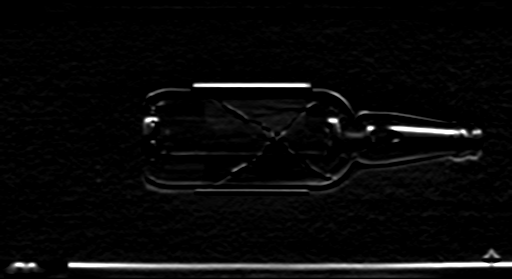

sobely


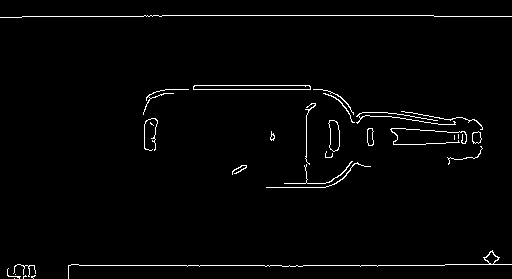

Canny Hysteresis
--- INSPECTION REPORT ---
ROI Edge Density: 2.76%
STATUS: CRITICAL DEFECT DETECTED - REJECT BOTTLE


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow # Specific for Colab visualization

# 1. LOAD IMAGE
# Students should upload the 'cracked_bottle.jpg' and 'control_bottle.png' to Colab files
path = '/content/cracked.jpeg'
img = cv2.imread(path)
cv2_imshow(img)
if img is None:
    print("Error: Image not found. Please upload 'cracked_bottle.jpg' to the Colab file explorer.")
else:
    # 2. PRE-PROCESSING (Noise Suppression)
    # Industrial target: Conv-belt texture must be blurred out
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (7, 7), 0)
    cv2_imshow(blurred)

    # 3. FEATURE EXTRACTION (Directional Gradients)
    # Sobel X: Detects vertical cracks | Sobel Y: Detects horizontal cracks
    sobelx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
    cv2_imshow(sobelx)
    print("sobelx")
    cv2_imshow(sobely)
    print("sobely")
    # 4. STRUCTURAL ISOLATION (Canny Edge Detection)
    # High/Low thresholds tuned for the glass-on-belt contrast
    edges = cv2.Canny(blurred, 50, 150)
    cv2_imshow(edges)
    print("Canny Hysteresis")

    # Task: Calculate defect density to trigger an alarm
# Define ROI: Focusing on the bottle body (adjust coordinates based on image crop)
roi = edges[100:600, 200:800]

edge_pixels = np.count_nonzero(roi)
total_pixels = roi.shape[0] * roi.shape[1]
density = (edge_pixels / total_pixels) * 100

print(f"--- INSPECTION REPORT ---")
print(f"ROI Edge Density: {density:.2f}%")

# Decision Logic
THRESHOLD = 1.2 # Calibrated for the cracked bottle image
if density > THRESHOLD:
    print("STATUS: CRITICAL DEFECT DETECTED - REJECT BOTTLE")
else:
    print("STATUS: PASS")

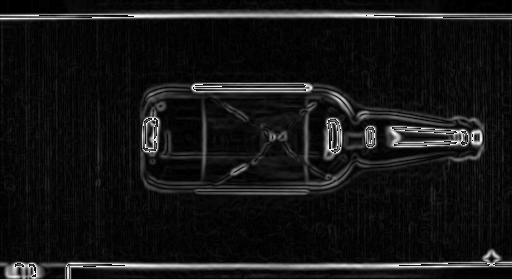

Gradient Magnitude (Combined Sobel X and Y)


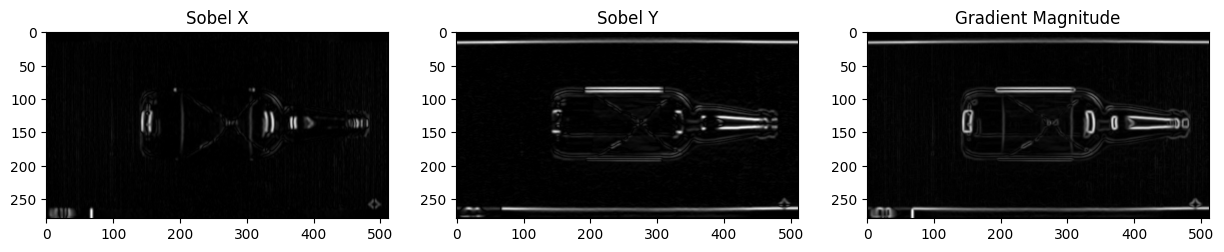

In [10]:
gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)
cv2_imshow(gradient_magnitude.astype(np.uint8))
print("Gradient Magnitude (Combined Sobel X and Y)")

# For better visualization of the combined effect alongside original Sobel images
plt.figure(figsize=(15, 5))
plt.subplot(131), plt.imshow(np.abs(sobelx), cmap='gray'), plt.title('Sobel X')
plt.subplot(132), plt.imshow(np.abs(sobely), cmap='gray'), plt.title('Sobel Y')
plt.subplot(133), plt.ims how(gradient_magnitude, cmap='gray'), plt.title('Gradient Magnitude')
plt.show()